# SDE foundations

Brownian motion, the Euler–Maruyama scheme, and two test equations with known solutions — the Ornstein–Uhlenbeck process and geometric Brownian motion. These implement the finite-dimensional theory of the report (Sections 3–4) and provide the benchmarks used in the convergence study.

In [1]:
import sys
from pathlib import Path

# Locate the project root (the folder containing src/) so the solver modules
# import cleanly and figures are written to figures/.
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
FIGURES = ROOT / "figures"

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import sde

Matplotlib is building the font cache; this may take a moment.


Five Brownian paths, an Ornstein–Uhlenbeck process relaxing to its long-run mean, and geometric Brownian motion with the Euler–Maruyama approximation plotted against the exact solution on the same path.

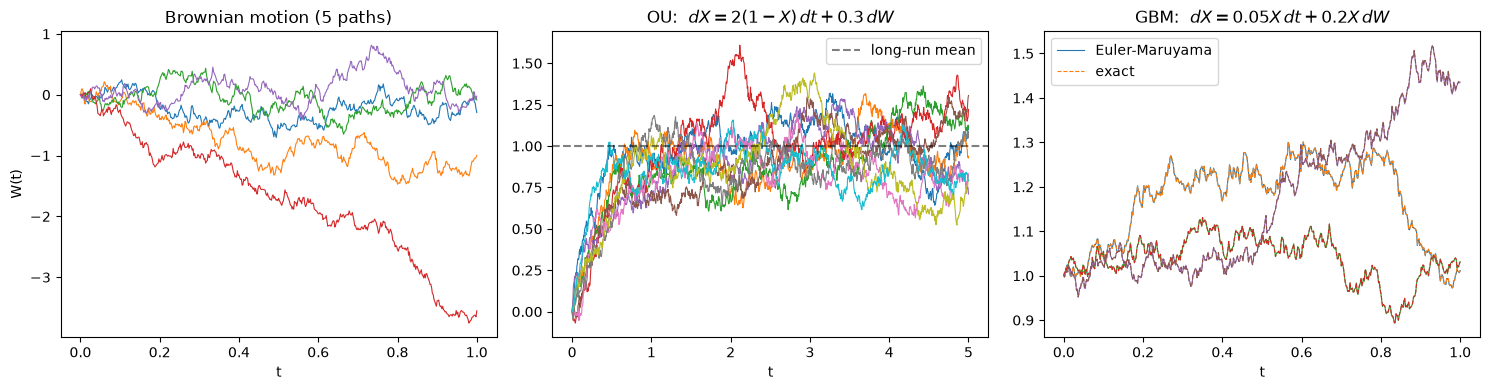

In [3]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Brownian motion
t, W = sde.simulate_bm(T=1.0, N=500, M=5, rng=rng)
axes[0].plot(t, W.T, lw=0.8)
axes[0].set_title("Brownian motion (5 paths)")
axes[0].set_xlabel("t")
axes[0].set_ylabel("W(t)")

# Ornstein-Uhlenbeck, mean-reverting to mu = 1
f, g = sde.ou(theta=2.0, mu=1.0, sigma=0.3)
t, X = sde.euler_maruyama(f, g, X0=0.0, T=5.0, N=1000, M=10, rng=rng)
axes[1].plot(t, X.T, lw=0.8)
axes[1].axhline(1.0, color="k", ls="--", alpha=0.5, label="long-run mean")
axes[1].set_title(r"OU:  $dX = 2(1-X)\,dt + 0.3\,dW$")
axes[1].set_xlabel("t")
axes[1].legend()

# Geometric Brownian motion: Euler-Maruyama against the exact path
f, g = sde.gbm(mu=0.05, sigma=0.2)
t, X, dW = sde.euler_maruyama(f, g, X0=1.0, T=1.0, N=500, M=3, rng=rng, return_dW=True)
W_path = np.concatenate([np.zeros((3, 1)), np.cumsum(dW, axis=1)], axis=1)
X_exact = sde.gbm_exact(X0=1.0, mu=0.05, sigma=0.2, t=t, W=W_path)
for i in range(3):
    axes[2].plot(t, X[i], lw=0.8, label="Euler-Maruyama" if i == 0 else None)
    axes[2].plot(t, X_exact[i], lw=0.8, ls="--", label="exact" if i == 0 else None)
axes[2].set_title(r"GBM:  $dX = 0.05X\,dt + 0.2X\,dW$")
axes[2].set_xlabel("t")
axes[2].legend()

fig.tight_layout()
fig.savefig(FIGURES / "m2r_overview.png", dpi=120)
plt.show()